In [1]:
import pandas as pd

df = pd.read_csv('tesla_stock.csv')

In [2]:
df.head()

,Date,Close
0,2010-06-30 00:00:00-04:00,1.588667
1,2010-07-01 00:00:00-04:00,1.464000
2,2010-07-02 00:00:00-04:00,1.280000
3,2010-07-06 00:00:00-04:00,1.074000
4,2010-07-07 00:00:00-04:00,1.053333


In [3]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)

In [4]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
	x=df['Date'],
	y=df['Close'],
	mode='lines',
	line=dict(color='blue')
))

fig.update_layout(
	title='Tesla Daily Closing Price (2010-2026)',
	xaxis_title='Date',
	yaxis_title='Stock Price (USD)',
	hovermode='x unified',
	template='plotly_white',
	showlegend=False
)

fig.show()

In [5]:
'''===========================STEP 1.2 ============================'''

import plotly.graph_objects as go

# Convert the date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Add moving averages
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA90'] = df['Close'].rolling(window=90).mean()

# Create interactive line chart
fig = go.Figure()

# Daily closing price
fig.add_trace(go.Scatter(
	x=df['Date'],
	y=df['Close'],
	mode='lines',
	name='Daily Close',
	line=dict(color='blue')
))

# 30-day moving average
fig.add_trace(go.Scatter(
	x=df['Date'],
	y=df['MA30'],
	mode='lines',
	name='30-Day MA',
	line=dict(color='orange', dash='dash')
))

# 90-day moving average
fig.add_trace(go.Scatter(
	x=df['Date'],
	y=df['MA90'],
	mode='lines',
	name='90-Day MA',
	line=dict(color='green', dash='dot')
))

# Layout customization
fig.update_layout(
	title='Tesla Stock Prices (2010-2026)',
	xaxis_title='Date',
	yaxis_title='Stock Price (USD)',
	hovermode='x unified',
	template='plotly_white',
	legend=dict(x=0, y=1.1, orientation='h')
)

fig.show()

In [6]:
!pip install pmdarima
!pip install pymannkendall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 592.4/592.4 kB 12.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]


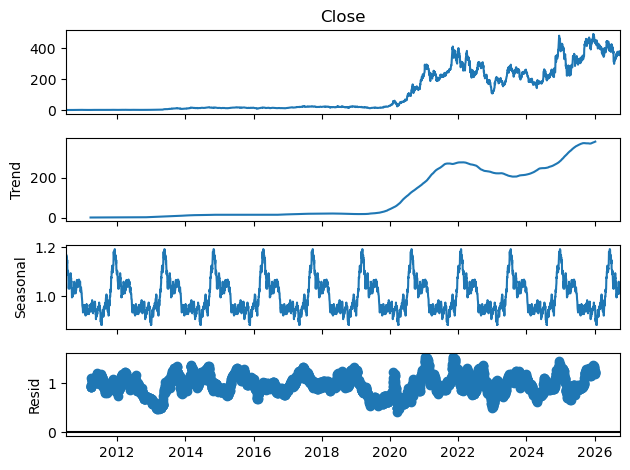

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Set date as index
df_ts = df.set_index('Date')

# Decompose (daily frequency)
result = seasonal_decompose(df_ts['Close'], model='multiplicative', period=365)

# Plot
result.plot()
plt.show()

In [8]:
import pymannkendall as mk

trend_test = mk.original_test(df['Close'])
print(trend_test)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(77.47307731303826), Tau=np.float64(0.808146397076885), s=np.float64(6751116.0), var_s=np.float64(7593629399.333333), slope=np.float64(0.0779429848397822), intercept=np.float64(-138.47415664198212))


In [9]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN from differencing
df_diff = df['Close'].dropna()

# Perform ADF test
adf_result = adfuller(df_diff)

print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
print("Critical Values:")
for key, value in adf_result[4].items():
	print(f"   {key}: {value:.4f}")

ADF Statistic: -1.1284
p-value: 0.7036
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5671


/var/folders/qr/qqkx12110914k3tn4fmdfr480000gn/T/ipykernel_11913/1270783863.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df_diff)


In [10]:
'''Detrending using differening'''

df['Close_diff'] = df['Close'].diff()  # simple daily difference

In [11]:
import plotly.graph_objects as go

# Drop the first NaN from differencing
df_diff = df['Close_diff'].dropna()

fig = go.Figure()

fig.add_trace(go.Scatter(
	x=df['Date'].iloc[1:],
	y=df_diff,
	mode='lines',
	name='Daily Difference',
	line=dict(color='purple')
))

fig.update_layout(
	title='Tesla Daily Price Changes (Differenced)',
	xaxis_title='Date',
	yaxis_title='Price Change (USD)',
	template='plotly_white',
	hovermode='x unified'
)

fig.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN from differencing
df_diff = df['Close_diff'].dropna()

# Perform ADF test
adf_result = adfuller(df_diff)

print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
print("Critical Values:")
for key, value in adf_result[4].items():
	print(f"   {key}: {value:.4f}")

ADF Statistic: -11.8721
p-value: 0.0000
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5671


/var/folders/qr/qqkx12110914k3tn4fmdfr480000gn/T/ipykernel_11913/1541861140.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df_diff)


In [13]:
import pmdarima as pm
import pandas as pd

# Use ORIGINAL series (not differenced)
ts = df['Close'].dropna()

criteria = ['aic', 'bic', 'hqic', 'aicc']
best_orders = {}

for crit in criteria:
	model = pm.auto_arima(
    	ts,
    	start_p=0, max_p=10,
    	start_q=0, max_q=10,
    	d=None,        	# Let auto_arima determine differencing
    	max_d=2,       	# Maximum differencing order
    	seasonal=False,
    	information_criterion=crit,
    	stepwise=True,
    	suppress_warnings=True,
    	error_action='ignore',
    	trace=False    	# Set to True if you want to see the search process
	)
	best_orders[crit.upper()] = model.order

# Convert to DataFrame
best_orders_df = pd.DataFrame(best_orders).T
best_orders_df.columns = ['p', 'd', 'q']

print(best_orders_df)

      p  d  q
AIC   1  1  0
BIC   0  1  0
HQIC  0  1  0
AICC  1  1  0


In [14]:
import pmdarima as pm
import pandas as pd

# Stationary series
ts = df['Close_diff'].dropna()

# Criteria list
criteria = ['aic', 'bic', 'hqic', 'aicc']
best_orders = {}

for crit in criteria:
	model = pm.auto_arima(
    	ts,
    	start_p=0, max_p=10,
    	start_q=0, max_q=10,
    	d=0,           	# already differenced
    	seasonal=False,	# ARMA
    	information_criterion=crit,
    	stepwise=True, 	# fast stepwise search
    	suppress_warnings=True,
    	error_action='ignore'
	)
	best_orders[crit.upper()] = model.order  # tuple (p,d,q)

# Convert to DataFrame with separate columns
best_orders_df = pd.DataFrame(best_orders).T  # transpose
best_orders_df.columns = ['p','d','q']

print(best_orders_df)

      p  d  q
AIC   1  0  0
BIC   0  0  0
HQIC  1  0  0
AICC  1  0  0


In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Stationary series
ts = df['Close_diff'].dropna()

# Fit ARMA/ARIMA model (ARIMA(1,0,0))
model = sm.tsa.ARIMA(ts, order=(1,0,0))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -13340.681
Date:                Fri, 02 Oct 2026   AIC                          26687.362
Time:                        17:34:50   BIC                          26706.309
Sample:                             0   HQIC                         26694.071
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0864      0.096      0.904      0.366      -0.101       0.274
ar.L1         -0.0367      0.009     -4.206      0.000      -0.054      -0.020
sigma2        40.0708      0.337    118.751      0.0

/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


In [16]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

ts = df['Close_diff'].dropna()

# Compare both models
models_to_test = {
	'ARMA(0,0) - White Noise': (0, 0, 0),
	'ARMA(1,0) - AR(1)': (1, 0, 0)
}

results_comparison = []

for name, order in models_to_test.items():
	model = sm.tsa.ARIMA(ts, order=order)
	result = model.fit()
    
	# Ljung-Box test on residuals (p > 0.05 means residuals are white noise - good!)
	lb_test = acorr_ljungbox(result.resid, lags=10, return_df=True)
    
	results_comparison.append({
    	'Model': name,
    	'AIC': result.aic,
    	'BIC': result.bic,
    	'HQIC': result.hqic,
    	'AICC': result.aicc,
    	'Ljung-Box p-value (lag 10)': lb_test['lb_pvalue'].iloc[-1]
	})
    
	print(f"\n{'='*60}")
	print(f"{name}")
	print(f"{'='*60}")
	print(result.summary())

# Compare models
import pandas as pd
comparison_df = pd.DataFrame(results_comparison)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)



ARMA(0,0) - White Noise
                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                          ARIMA   Log Likelihood              -13343.453
Date:                Fri, 02 Oct 2026   AIC                          26690.905
Time:                        18:07:01   BIC                          26703.536
Sample:                             0   HQIC                         26695.378
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0864      0.099      0.872      0.383      -0.108       0.281
sigma2        40.1181      0.338    118.667      0.000      39.455      40.781
Ljung-Box (L1) (Q):        

/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


In [17]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 10.3 MB/s  0:00:00


In [18]:
from arch import arch_model

# Pure GARCH without AR term
model = arch_model(
	ts,
	mean='Constant',  # Just a constant, no AR
	vol='GARCH',
	p=1, q=1,
	dist='t'      	# Student-t for fat tails
)
result = model.fit(disp='off')
print(result.summary())

print("mu: mean return → average daily return of the series")
print("omega: base volatility → long-run variance floor, minimum level of volatility")
print("alpha: shock impact → effect of yesterday's return shocks on today's volatility")
print("beta: volatility persistence → effect of yesterday's volatility on today's volatility")
print("nu: fat-tail parameter → allows for extreme returns beyond normal distribution")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Close_diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6045.20
Distribution:      Standardized Student's t   AIC:                           12100.4
Method:                  Maximum Likelihood   BIC:                           12132.0
                                              No. Observations:                 4087
Date:                      Fri, Oct 02 2026   Df Residuals:                     4086
Time:                              18:24:09   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [19]:
# 1. Standardized residuals should be white noise
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract standardized residuals
std_resid = result.resid / result.resid.std()


# 2. Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)
print("\nLjung-Box Test: Autocorrelation (p > 0.05 is good):")
print(lb_test)


# 3. ARCH-LM test (no remaining ARCH effects)
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(result.resid, nlags=10)
print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no remaining ARCH effects)")
print("If p-value is below 0.05, the model may need higher-order GARCH terms. This suggests that there exists higher-order volatility clustering in the residuals.")


Ljung-Box Test: Autocorrelation (p > 0.05 is good):
      lb_stat  lb_pvalue
1    5.544582   0.018538
2    5.640970   0.059577
3    5.818676   0.120773
4    5.819834   0.213013
5    5.878064   0.318265
6    6.931688   0.327211
7   12.583714   0.082924
8   13.944576   0.083222
9   24.039223   0.004240
10  27.492075   0.002176

ARCH-LM Test statistic: 507.4461, p-value: 0.0000
(p > 0.05 → no remaining ARCH effects)
If p-value is below 0.05, the model may need higher-order GARCH terms. This suggests that there exists higher-order volatility clustering in the residuals.


/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


    Day  Forecasted_Price  Volatility  Upper_1sigma  Lower_1sigma  \
0     1        354.813226    9.870356    364.683582    344.942871   
1     2        354.816455    9.870377    364.686832    344.946079   
2     3        354.819684    9.870398    364.690082    344.949286   
3     4        354.822913    9.870419    364.693332    344.952494   
4     5        354.826142    9.870440    364.696582    344.955702   
5     6        354.829371    9.870461    364.699832    344.958910   
6     7        354.832600    9.870482    364.703083    344.962118   
7     8        354.835829    9.870504    364.706333    344.965325   
8     9        354.839058    9.870525    364.709583    344.968533   
9    10        354.842287    9.870546    364.712833    344.971741   
10   11        354.845516    9.870567    364.716083    344.974949   
11   12        354.848745    9.870588    364.719333    344.978157   
12   13        354.851974    9.870609    364.722583    344.981364   
13   14        354.855203    9.870

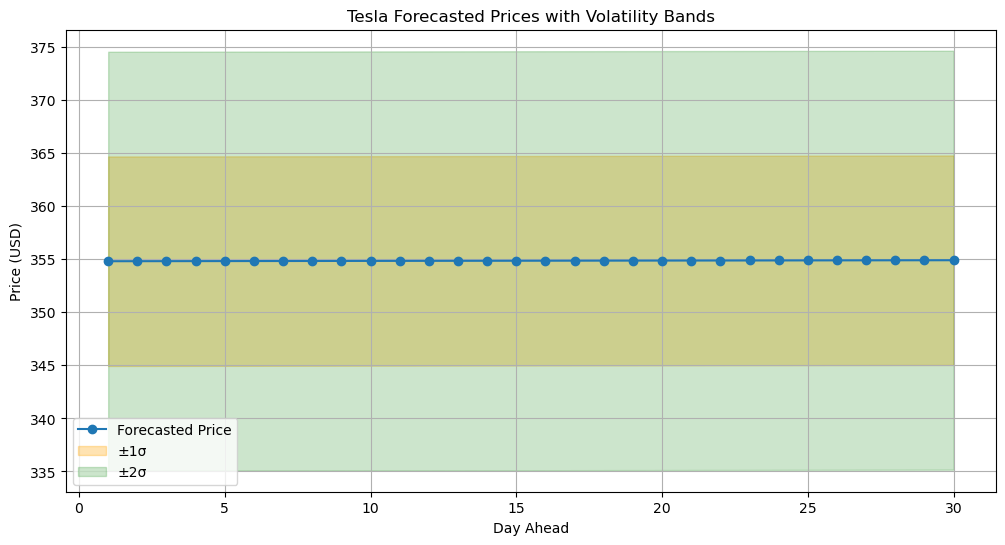

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Forecast horizon
horizon = 30  # next 30 days

# Forecast using fitted GARCH model
forecast = result.forecast(horizon=horizon)

# Extract mean forecast (returns) and conditional volatility
mean_forecast = forecast.mean.values[-1, :]  # predicted daily changes
vol_forecast = np.sqrt(forecast.variance.values[-1, :])  # conditional std dev

# Reconstruct forecasted prices from last known closing price
last_price = df['Close'].iloc[-1]
price_forecast = [last_price]
for ret in mean_forecast:
	price_forecast.append(price_forecast[-1] + ret)

price_forecast = price_forecast[1:]  # remove initial last price

# Create DataFrame
forecast_df = pd.DataFrame({
	'Day': range(1, horizon+1),
	'Forecasted_Price': price_forecast,
	'Volatility': vol_forecast
})

# Compute 1-sigma and 2-sigma bands
forecast_df['Upper_1sigma'] = forecast_df['Forecasted_Price'] + forecast_df['Volatility']
forecast_df['Lower_1sigma'] = forecast_df['Forecasted_Price'] - forecast_df['Volatility']
forecast_df['Upper_2sigma'] = forecast_df['Forecasted_Price'] + 2*forecast_df['Volatility']
forecast_df['Lower_2sigma'] = forecast_df['Forecasted_Price'] - 2*forecast_df['Volatility']

# Display forecast table
print(forecast_df)

# Plot forecast with volatility bands
plt.figure(figsize=(12,6))
plt.plot(forecast_df['Day'], forecast_df['Forecasted_Price'], marker='o', label='Forecasted Price')
plt.fill_between(forecast_df['Day'], forecast_df['Lower_1sigma'], forecast_df['Upper_1sigma'], color='orange', alpha=0.3, label='±1σ')
plt.fill_between(forecast_df['Day'], forecast_df['Lower_2sigma'], forecast_df['Upper_2sigma'], color='green', alpha=0.2, label='±2σ')
plt.title("Tesla Forecasted Prices with Volatility Bands")
plt.xlabel("Day Ahead")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import scipy.stats as stats

# =========================
# 1. Fit ARIMA(1,0,0) on Close_diff
# =========================

In [22]:
ts = df['Close_diff'].dropna().reset_index(drop=True)

model = ARIMA(ts, order=(1,0,0))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -13340.681
Date:                Fri, 02 Oct 2026   AIC                          26687.362
Time:                        18:42:05   BIC                          26706.309
Sample:                             0   HQIC                         26694.071
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0864      0.096      0.904      0.366      -0.101       0.274
ar.L1         -0.0367      0.009     -4.206      0.000      -0.054      -0.020
sigma2        40.0708      0.337    118.751      0.0

# =========================
# 2. Residual diagnostics
# =========================

In [23]:
resid = result.resid
std_resid = resid / resid.std()

# Ljung-Box test
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)

print("\nLjung-Box Test (p > 0.05 → no significant autocorrelation):")
print(lb_test)

# ARCH-LM test
arch_test = het_arch(resid, nlags=10)

print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}")
print(f"ARCH-LM p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no significant ARCH effects)")


Ljung-Box Test (p > 0.05 → no significant autocorrelation):
      lb_stat  lb_pvalue
1    0.000011   0.997369
2    0.043815   0.978331
3    0.213655   0.975355
4    0.217059   0.994520
5    0.259245   0.998340
6    1.486442   0.960390
7    7.144132   0.414029
8    8.076612   0.426022
9   17.529638   0.041040
10  20.585772   0.024175

ARCH-LM Test statistic: 503.6998
ARCH-LM p-value: 0.0000
(p > 0.05 → no significant ARCH effects)


/opt/anaconda3/envs/networks/lib/python3.11/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


# =========================
# 3. Forecast next 30 days
# =========================

In [24]:
horizon = 30

forecast = result.get_forecast(steps=horizon)
mean_forecast = forecast.predicted_mean.values

# Reconstruct forecasted prices
last_price = df['Close'].iloc[-1]

price_forecast = [last_price]

for change in mean_forecast:
	price_forecast.append(price_forecast[-1] + change)

price_forecast = price_forecast[1:]

# Forecast DataFrame
forecast_df = pd.DataFrame({
	'Day': range(1, horizon + 1),
	'Forecasted_Price': price_forecast
})

print("\n30-Day Forecast:")
print(forecast_df)


30-Day Forecast:
    Day  Forecasted_Price
0     1        354.827213
1     2        354.916178
2     3        355.002507
3     4        355.088933
4     5        355.175356
5     6        355.261779
6     7        355.348201
7     8        355.434624
8     9        355.521047
9    10        355.607469
10   11        355.693892
11   12        355.780315
12   13        355.866737
13   14        355.953160
14   15        356.039583
15   16        356.126005
16   17        356.212428
17   18        356.298851
18   19        356.385274
19   20        356.471696
20   21        356.558119
21   22        356.644542
22   23        356.730964
23   24        356.817387
24   25        356.903810
25   26        356.990232
26   27        357.076655
27   28        357.163078
28   29        357.249500
29   30        357.335923


# =========================
# 4. Plot forecast
# =========================

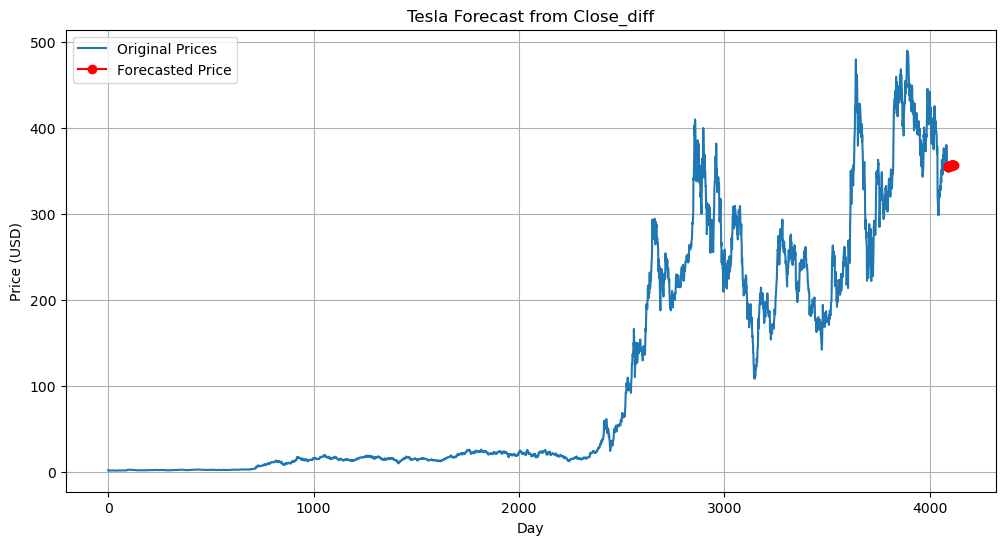

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
	df['Close'].values,
	label='Original Prices'
)

plt.plot(
	range(len(df['Close']), len(df['Close']) + horizon),
	price_forecast,
	marker='o',
	color='red',
	label='Forecasted Price'
)

plt.title("Tesla Forecast from Close_diff")
plt.xlabel("Day")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 5. Simplified VaR
# =========================

In [26]:
current_price = df['Close'].iloc[-1]

# Residual standard deviation in USD
resid_vol = resid.std()

# Student-t quantile
t_quantile = stats.t.ppf(0.05, df=4)

# Simplified 95% VaR
VaR_95 = current_price * (resid_vol / current_price) * t_quantile

print(f"\nCurrent Tesla Price: ${current_price:.2f}")
print(f"Estimated residual volatility: ${resid_vol:.4f}")
print(f"95% VaR (simplified, teaching): ${abs(VaR_95):.2f}")


Current Tesla Price: $354.81
Estimated residual volatility: $6.3304
95% VaR (simplified, teaching): $13.50
